# U.S. Equity Market Regimes — Gaussian Mixture Model (point-in-time)

Classify the U.S. market environment into latent regimes with a **Gaussian Mixture Model (GMM)** fed by
cross-asset data (equity, volatility, credit, rates, inflation expectations, gold) plus the
historical performance of the **S&P 500 Total Return index (SPXTR)**, then study

1. the **economic profile** of each regime (mean and S.D. of every variable), and
2. the **forward return of SPXTR** conditional on the regime,
3. whether a **Kalman filter** (on the inputs or on the regime probabilities) improves the classification, and
4. the **forward returns of the S&P 500 sectors** in each regime.

**Point-in-time design (no look-ahead)**

| Risk of look-ahead | How it is handled |
|---|---|
| Publication lag of ICE BofA / FRED series (OAS, corporate yields, TIPS, breakevens) | Shifted by **1 trading day** before use |
| Feature construction | Trailing windows only (returns, vol, drawdown, changes, de-trending) |
| Scaling / PCA / GMM fitted on the full sample | **Walk-forward**: expanding window, re-fit every quarter, only data available at the re-fit date |
| Label switching between re-fits | Each new fit is aligned to the previous one (Hungarian matching on the training data) — never to a future model |
| Choice of K | Driven by **walk-forward out-of-sample log-likelihood** + stability + economic constraints — forward returns are **never** used |
| Forward returns | Used only for evaluation, measured from the **next trading day's close** after the classification week |
| Kalman filter (Section 10) | Forward filter only (no smoother); its parameters are estimated on each re-fit's training window |

In [22]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

ROOT = Path('../')
DATA_DIR = ROOT / 'data/tradingview/us_regime'

# ---- model settings ----
SEED = 42
N_PCS = 6              # PCA components fed to the GMM (~77% of variance)
COV_TYPE = 'full'
REG_COVAR = 1e-3
N_INIT = 10
N_INIT_DIAG = 50      # more EM restarts for the one-off full-sample K diagnostics (avoids poor local optima)
K_RANGE = range(1, 9)
INIT_WEEKS = 156       # first training window (3 years) before the first out-of-sample label
REFIT_EVERY = 13       # re-fit the model every quarter (13 weeks)
OOS_FOLD = 52          # out-of-sample fold length for K selection (1 year)
MIN_SHARE = 0.05       # economic constraint: every regime >= 5% of weeks
MIN_DURATION = 4       # economic constraint: average spell >= 4 weeks (~1 month)
HORIZONS = {'1m': 4, '3m': 13, '6m': 26, '12m': 52}   # forward horizons in weeks

# ---- chart style (recessive chrome, thin marks) ----
INK, INK_2, MUTED, GRID, AXIS, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
DIVERGING = LinearSegmentedColormap.from_list('div', ['#184f95', '#6da7ec', '#f0efec', '#ec8d8c', '#b3302f'])
SEQUENTIAL = LinearSegmentedColormap.from_list('seq', ['#f0efec', '#9ec5f4', '#3987e5', '#184f95'])
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'font.family': 'sans-serif', 'font.size': 9.5,
    'text.color': INK, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'axes.titlesize': 11,
    'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.edgecolor': AXIS,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2, 'legend.frameon': False, 'axes.axisbelow': True,
})

## 1. Load data

Daily TradingView export. `close` is **SPXTR**; the remaining columns are cross-asset series.

In [23]:
RENAME = {
    'close': 'spxtr',
    'Cboe 20+ Year Treasury Bond ETF Volatility Basis Point Index · CBOE: close': 'tlt_vol_bp',
    'Cboe S&P 500 Constituent Volatility Index · CBOE: close': 'vixeq',
    'Cboe 1-Month Implied Correlation Index · CBOE: close': 'impl_corr',
    'PUT/CALL RATIO (EQUITIES) - CBOE · USI: close': 'put_call',
    'ICE BofA CCC & Lower US High Yield Index Option-Adjusted Spread · ICE: close': 'ccc_oas',
    'West Texas Intermediate Crude Oil cash · BlackBull Markets: close': 'wti',
    'CFDs on Gold (US$ / OZ) · TVC: close': 'gold',
    'ICE BofA AAA US Corporate Index Option-Adjusted Spread · ICE: close': 'aaa_oas',
    'ICE BofA 7-10 Year US Corporate Index Effective Yield · ICE: close': 'corp_7_10y',
    'ICE BofA 1-3 Year US Corporate Index Effective Yield · ICE: close': 'corp_1_3y',
    'ICE BofA US Corporate Index Option-Adjusted Spread · ICE: close': 'ig_oas',
    'GOLD VOLATILITY INDEX · CBOE: close': 'gvz',
    'CBOE SKEW INDEX · CBOE: close': 'skew',
    'Volatility S&P 500 Index · TVC: close': 'vix',
    'ICE BofAML U.S. Bond Market Option Volatility Estimate Index · TVC: close': 'move',
    '30-Year Treasury Inflation-Indexed Security, Constant Maturity · Federal Reserve: close': 'tips_30y',
    '10-Year Treasury Inflation-Indexed Security, Constant Maturity · Federal Reserve: close': 'tips_10y',
    '5-Year, 5-Year Forward Inflation Expectation Rate · Federal Reserve Bank of St. Louis: close': 'be_5y5y',
    '5-Year Breakeven Inflation Rate · Federal Reserve Bank of St. Louis: close': 'be_5y',
    '10-Year Breakeven Inflation Rate · Federal Reserve Bank of St. Louis: close': 'be_10y',
    'United States 30 Year Government Bonds Yield · TVC: close': 'ust_30y',
    'US Government Bonds 10 YR Yield · TVC: close': 'ust_10y',
    'US Government Bonds 2 YR Yield · TVC: close': 'ust_2y',
    'United States 3 Month Government Bonds Yield · TVC: close': 'ust_3m',
}

def to_date(col: pd.Series) -> pd.Series:
    """TradingView `time` column: 'YYYY-MM-DD' strings (current export) or Unix seconds (older exports)."""
    if pd.api.types.is_numeric_dtype(col):
        return pd.to_datetime(col, unit='s').dt.normalize()
    return pd.to_datetime(col, format='%Y-%m-%d')


frames = []
for f in sorted(DATA_DIR.glob('*.csv')):
    df = pd.read_csv(f)
    df['date'] = to_date(df['time'])
    frames.append(df.drop(columns='time').set_index('date'))
raw = pd.concat(frames).sort_index()
raw = raw[~raw.index.duplicated(keep='last')]

missing_cols = set(RENAME) - set(raw.columns)
assert not missing_cols, f'Unexpected schema, missing: {missing_cols}'
raw = raw.rename(columns=RENAME)[list(RENAME.values())]

coverage = pd.DataFrame({
    'first': raw.apply(lambda c: c.first_valid_index()).dt.date,
    'last': raw.apply(lambda c: c.last_valid_index()).dt.date,
    'obs': raw.count(),
}).sort_values('first')
print(f'{len(raw):,} daily rows, {raw.index[0].date()} → {raw.index[-1].date()}')
coverage

7,256 daily rows, 1997-11-26 → 2026-09-28


,first,last,obs
spxtr,1997-11-26,2026-09-28,7256
ust_10y,1997-11-26,2026-09-28,6493
ust_30y,1997-11-26,2026-09-28,6466
vix,1997-11-26,2026-09-28,7252
skew,1997-11-26,2026-09-28,7189
ust_2y,1997-11-26,2026-09-28,6585
ig_oas,1997-11-26,2026-09-25,7249
corp_1_3y,1997-11-26,2026-09-25,7250
corp_7_10y,1997-11-26,2026-09-25,7250
ust_3m,1997-11-26,2026-09-28,7181


## 2. Point-in-time preprocessing

* **Publication lag** — ICE BofA indices (OAS, corporate yields) and FRED series (TIPS yields, breakevens) for day *t*
  are published on *t+1*. They are shifted by one trading day so that the value used on day *t* was actually known on *t*.
  Market prices (SPXTR, VIX, MOVE, GVZ, SKEW, put/call, Treasury yields, gold, WTI) are known at the close of *t*.
* **Gaps** (holidays / missing prints) are forward-filled for at most 5 trading days — forward-filling uses only past data.

In [24]:
PUB_LAG_COLS = ['ccc_oas', 'aaa_oas', 'ig_oas', 'corp_7_10y', 'corp_1_3y',
                'tips_30y', 'tips_10y', 'be_5y5y', 'be_5y', 'be_10y']

daily = raw.copy()
daily[PUB_LAG_COLS] = daily[PUB_LAG_COLS].shift(1)
daily = daily.ffill(limit=5)

## 3. Feature engineering

GMM clusters on the joint distribution of its inputs, so the inputs must be **stationary enough for regimes to recur**.
Feeding raw levels of yields or breakevens makes the GMM split history into calendar *eras* (e.g. "ZIRP 2010-15" vs
"post-2022") that can only be recognised with hindsight. Therefore:

* **Stress / sentiment gauges that mean-revert** (VIX, MOVE, GVZ, credit spreads, implied correlation) enter as (log) levels.
* **Trending sentiment series** (SKEW, equity put/call) enter as deviations from their trailing 1-year mean.
* **Rates & inflation** enter as **3-month changes** (rate-of-change = the macro *impulse*: tightening/easing, reflation/disinflation).
* **SPXTR performance** enters as 1m/3m/12m return, 1m realised vol and drawdown from the 52-week high.

**Sample.** Every model input must be observed at each date, so the model sample starts when the last required series
begins (**GVZ, Aug-2008**), which still covers the GFC, 2011, 2015-16, 2018, COVID and 2022.
Four series start too late to be model inputs without cutting the sample to a few years:
`tlt_vol_bp` (2024), `wti` (2017), `vixeq` (2014) and `tips_30y` (2010). They are **not discarded** — they are used to
describe the regimes in Section 7 over the period where they exist. (Their information is also largely spanned by
model inputs: VIXEQ ≈ VIX / √implied-correlation, TLT vol ≈ MOVE, 30y TIPS ≈ 10y TIPS; WTI is partly reflected in breakevens.)

In [25]:
px = daily['spxtr']
logret = np.log(px).diff()
TD_1M, TD_3M, TD_12M = 21, 63, 252

F = pd.DataFrame(index=daily.index)
# SPXTR performance
F['spx_ret_1m'] = px.pct_change(TD_1M)
F['spx_ret_3m'] = px.pct_change(TD_3M)
F['spx_ret_12m'] = px.pct_change(TD_12M)
F['spx_rvol_1m'] = logret.rolling(TD_1M).std() * np.sqrt(252)
F['spx_dd_52w'] = px / px.rolling(TD_12M).max() - 1
# Equity volatility & sentiment
F['log_vix'] = np.log(daily['vix'])
F['vrp'] = daily['vix'] / 100 - F['spx_rvol_1m']            # implied minus realised vol
F['skew_dev'] = daily['skew'] - daily['skew'].rolling(TD_12M, min_periods=200).mean()
F['impl_corr'] = daily['impl_corr'].rolling(5, min_periods=3).median()   # damp index-roll noise
F['put_call_dev'] = (daily['put_call'].rolling(10, min_periods=5).mean()
                     - daily['put_call'].rolling(TD_12M, min_periods=200).mean())
# Cross-asset volatility
F['log_move'] = np.log(daily['move'])
F['log_gvz'] = np.log(daily['gvz'])
# Credit
F['log_ig_oas'] = np.log(daily['ig_oas'])
F['log_aaa_oas'] = np.log(daily['aaa_oas'])
F['log_ccc_oas'] = np.log(daily['ccc_oas'])
F['ccc_oas_chg_3m'] = np.log(daily['ccc_oas']).diff(TD_3M)
F['corp_1_3y_chg_3m'] = daily['corp_1_3y'].diff(TD_3M)
F['corp_7_10y_chg_3m'] = daily['corp_7_10y'].diff(TD_3M)
# Rates (impulse)
for c in ['ust_3m', 'ust_2y', 'ust_10y', 'ust_30y']:
    F[f'{c}_chg_3m'] = daily[c].diff(TD_3M)
F['slope_10y2y_chg_3m'] = (daily['ust_10y'] - daily['ust_2y']).diff(TD_3M)
F['slope_10y3m_chg_3m'] = (daily['ust_10y'] - daily['ust_3m']).diff(TD_3M)
# Real yields & inflation expectations (impulse)
F['tips_10y_chg_3m'] = daily['tips_10y'].diff(TD_3M)
F['be_5y_chg_3m'] = daily['be_5y'].diff(TD_3M)
F['be_10y_chg_3m'] = daily['be_10y'].diff(TD_3M)
F['be_5y5y_chg_3m'] = daily['be_5y5y'].diff(TD_3M)
# Gold
F['gold_ret_3m'] = np.log(daily['gold']).diff(TD_3M)
F['gold_ret_12m'] = np.log(daily['gold']).diff(TD_12M)

FEATURES = list(F.columns)
print(f'{len(FEATURES)} model features')

30 model features


### Weekly sampling and forward returns

Regimes are classified **weekly** on the last trading day of each week — less noise than daily and ample observations.
The regime of week *t* is known at the close of its last trading day, so the forward return is measured from the
**next trading day's close** (a one-day execution lag) to the corresponding close *h* weeks later.

In [26]:
week_end = px.index.to_series().resample('W-FRI').last()   # actual last trading day of each week
weekly = F.resample('W-FRI').last().set_index(pd.DatetimeIndex(week_end.values, name='date'))
weekly_px = px.resample('W-FRI').last().set_axis(weekly.index)

X = weekly.dropna()
print(f'Model sample: {X.index[0].date()} → {X.index[-1].date()}  ({len(X)} weeks)')

entry_px = px.shift(-1).resample('W-FRI').last().set_axis(weekly.index)   # close of the next trading day
fwd = pd.DataFrame({h: entry_px.shift(-n) / entry_px - 1 for h, n in HORIZONS.items()}).reindex(X.index)
fwd.describe().T[['count', 'mean', 'std']]

Model sample: 2008-08-01 → 2026-09-28  (949 weeks)


,count,mean,std
1m,944.000,0.010,0.048
3m,935.000,0.035,0.078
6m,922.000,0.074,0.103
12m,896.000,0.155,0.131


## 4. Choosing K

Pipeline: `StandardScaler → PCA(6) → GMM(full covariance)`. The 30 features are highly collinear (four Treasury tenors,
three breakevens, three spreads…), so PCA keeps the covariance matrices well-conditioned (6 PCs ≈ 77% of variance);
otherwise a full-covariance GMM on 30 dimensions has ~500 parameters per component.

Four lenses:

1. **In-sample BIC / AIC** — classic, but weekly observations are highly autocorrelated, so the effective sample is far
   smaller than N and BIC under-penalises; it tends to keep decreasing.
2. **Walk-forward out-of-sample log-likelihood** (primary statistical criterion, point-in-time): fit on data up to year
   *y*, score the density of the next 52 weeks, roll forward.
3. **Stability** — Adjusted Rand Index (ARI) across random seeds and across block-bootstrap subsamples.
   (The full-sample fits behind lenses 1, 3 and 4 use 50 EM restarts: with 10 restarts the K = 4 fit can land in a
   visibly worse local optimum — higher BIC — whose smallest regime is ~3% instead of ~8%, flipping the decision.)
4. **Economic sense** — every regime must occupy ≥ 5% of weeks (enough data to estimate its forward returns) and last
   ≥ 4 weeks on average (a regime, not noise).

**Decision rule:** among K whose mean OOS log-likelihood is **not significantly worse than the best K** (paired t-stat of
the fold-by-fold gap > −2), pick the **largest K that satisfies the economic constraints** — the richest description
the data can support without a statistically significant loss of out-of-sample fit.

In [27]:
def make_model(k, seed=SEED, n_init=N_INIT):
    return make_pipeline(
        StandardScaler(),
        PCA(n_components=N_PCS, random_state=seed),
        GaussianMixture(n_components=k, covariance_type=COV_TYPE, reg_covar=REG_COVAR,
                        n_init=n_init, random_state=seed),
    )


# (2) walk-forward out-of-sample log-likelihood, annual folds
fold_starts = list(range(INIT_WEEKS, len(X) - OOS_FOLD + 1, OOS_FOLD))
oos_ll = pd.DataFrame(
    {k: [make_model(k).fit(X.iloc[:s]).score(X.iloc[s:s + OOS_FOLD]) for s in fold_starts] for k in K_RANGE},
    index=[X.index[s].date() for s in fold_starts],
)
oos_ll.index.name = 'OOS fold start'

# (1), (3), (4) on the full sample (descriptive diagnostics — not used to produce any label)
Z_full = make_pipeline(StandardScaler(), PCA(N_PCS, random_state=SEED)).fit_transform(X)
rng = np.random.default_rng(SEED)
blocks = np.array_split(np.arange(len(Z_full)), 20)
rows = []
for k in K_RANGE:
    gmm = GaussianMixture(k, covariance_type=COV_TYPE, reg_covar=REG_COVAR, n_init=N_INIT_DIAG, random_state=SEED).fit(Z_full)
    lab = gmm.predict(Z_full)
    if k > 1:
        ari_seed = np.mean([adjusted_rand_score(lab, GaussianMixture(k, covariance_type=COV_TYPE, reg_covar=REG_COVAR,
                            n_init=1, random_state=s).fit(Z_full).predict(Z_full)) for s in range(20)])
        ari_boot = []
        for b in range(20):
            keep = np.concatenate([blocks[i] for i in sorted(rng.choice(20, 16, replace=False))])
            g_b = GaussianMixture(k, covariance_type=COV_TYPE, reg_covar=REG_COVAR, n_init=3, random_state=b).fit(Z_full[keep])
            ari_boot.append(adjusted_rand_score(lab, g_b.predict(Z_full)))
        ari_boot = np.mean(ari_boot)
        sil = silhouette_score(Z_full, lab)
    else:
        ari_seed = ari_boot = 1.0
        sil = np.nan
    shares = np.bincount(lab, minlength=k) / len(lab)
    n_spells = (np.diff(lab) != 0).sum() + 1
    rows.append({'K': k, 'BIC': gmm.bic(Z_full), 'AIC': gmm.aic(Z_full), 'silhouette': sil,
                 'ARI_seed': ari_seed, 'ARI_block_boot': ari_boot,
                 'min_share': shares.min(), 'avg_duration_wk': len(lab) / n_spells})
k_diag = pd.DataFrame(rows).set_index('K')

best_k = oos_ll.mean().idxmax()
paired = oos_ll.sub(oos_ll[best_k], axis=0)
k_diag['OOS_LL_mean'] = oos_ll.mean()
k_diag['OOS_LL_gap_vs_best'] = paired.mean()
k_diag['OOS_LL_gap_se'] = paired.std(ddof=1) / np.sqrt(len(paired))
k_diag['OOS_LL_gap_t'] = (k_diag['OOS_LL_gap_vs_best'] / k_diag['OOS_LL_gap_se']).fillna(0)
k_diag['stat_ok'] = k_diag['OOS_LL_gap_t'] > -2
k_diag['econ_ok'] = (k_diag['min_share'] >= MIN_SHARE) & (k_diag['avg_duration_wk'] >= MIN_DURATION)
eligible = k_diag[(k_diag.index > 1) & k_diag['stat_ok'] & k_diag['econ_ok']]
K = int(eligible.index.max())
print(f'Best OOS K = {best_k};  eligible K = {list(eligible.index)};  ==> chosen K = {K}')
k_diag.round(3)

Best OOS K = 2;  eligible K = [2, 3, 4];  ==> chosen K = 4


,BIC,AIC,silhouette,ARI_seed,ARI_block_boot,min_share,avg_duration_wk,OOS_LL_mean,OOS_LL_gap_vs_best,OOS_LL_gap_se,OOS_LL_gap_t,stat_ok,econ_ok
K,,,,,,,,,,,,,
1,"22,801.100","22,670.004",NaN,1.000,1.000,1.000,949.000,-11.781,-0.391,0.300,-1.304,True,True
2,"20,846.863","20,579.815",0.425,0.937,0.847,0.168,29.656,-11.390,0.000,0.000,0.000,True,True
3,"20,380.229","19,977.231",0.107,0.377,0.223,0.098,13.557,-11.602,-0.212,0.200,-1.060,True,True
4,"20,132.438","19,593.488",0.096,0.376,0.249,0.080,9.038,-11.926,-0.536,0.368,-1.458,True,True
5,"19,963.042","19,288.140",0.106,0.490,0.346,0.031,9.038,-12.203,-0.812,0.437,-1.858,True,False
6,"19,758.326","18,947.473",0.086,0.411,0.388,0.031,9.396,-12.740,-1.350,0.460,-2.933,False,False
7,"19,717.938","18,771.133",0.100,0.374,0.412,0.028,9.490,-12.907,-1.517,0.475,-3.192,False,False
8,"19,616.416","18,533.660",0.100,0.429,0.430,0.032,6.285,-13.378,-1.988,0.604,-3.294,False,False


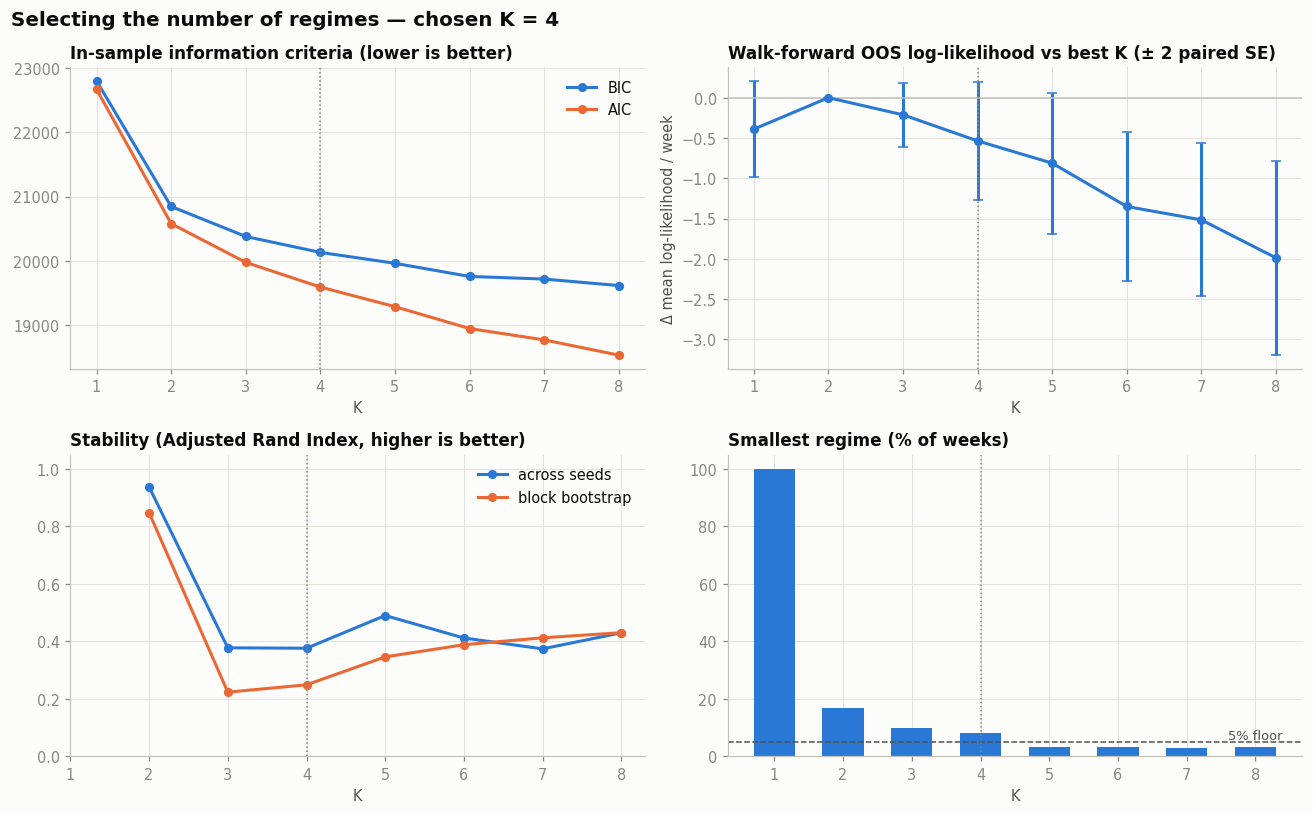

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
ks = list(K_RANGE)

ax = axes[0, 0]
ax.plot(ks, k_diag['BIC'], color=SERIES[0], marker='o', ms=5, label='BIC')
ax.plot(ks, k_diag['AIC'], color=SERIES[1], marker='o', ms=5, label='AIC')
ax.set_title('In-sample information criteria (lower is better)')
ax.legend()

ax = axes[0, 1]
ax.errorbar(ks, k_diag['OOS_LL_gap_vs_best'], yerr=2 * k_diag['OOS_LL_gap_se'], color=SERIES[0],
            marker='o', ms=5, capsize=3, lw=2)
ax.axhline(0, color=AXIS, lw=1)
ax.set_title('Walk-forward OOS log-likelihood vs best K (± 2 paired SE)')
ax.set_ylabel('Δ mean log-likelihood / week')

ax = axes[1, 0]
ax.plot(ks[1:], k_diag.loc[2:, 'ARI_seed'], color=SERIES[0], marker='o', ms=5, label='across seeds')
ax.plot(ks[1:], k_diag.loc[2:, 'ARI_block_boot'], color=SERIES[1], marker='o', ms=5, label='block bootstrap')
ax.set_ylim(0, 1.05)
ax.set_title('Stability (Adjusted Rand Index, higher is better)')
ax.legend()

ax = axes[1, 1]
ax.bar(ks, k_diag['min_share'] * 100, color=SERIES[0], width=0.6)
ax.axhline(MIN_SHARE * 100, color=INK_2, lw=1, ls='--')
ax.text(ks[-1] + 0.4, MIN_SHARE * 100, f'{MIN_SHARE:.0%} floor', va='bottom', ha='right', color=INK_2, fontsize=8.5)
ax.set_title('Smallest regime (% of weeks)')

for ax in axes.flat:
    ax.set_xticks(ks)
    ax.set_xlabel('K')
    ax.axvline(K, color=MUTED, lw=1, ls=':')
fig.suptitle(f'Selecting the number of regimes — chosen K = {K}', x=0.01, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout()
plt.show()

## 5. Walk-forward (point-in-time) regime classification

* The first model is fit on the first 3 years (Aug-2008 → Jul-2011).
* Every 13 weeks the pipeline (scaler, PCA, GMM) is **re-fit on all data available to date** and used to classify the
  following 13 weeks. No label ever comes from a model that has seen that week.
* **Label alignment:** GMM component numbering is arbitrary, so every new fit is matched to the previous fit by
  classifying the new training set with both models and solving the assignment problem (Hungarian algorithm) on the
  agreement matrix. The alignment only uses data up to the re-fit date.

In [29]:
def align_labels(prev_model, prev_perm, new_model, X_ref, k):
    """Permutation mapping raw labels of new_model -> canonical ids (those of prev_model)."""
    prev_lab = prev_perm[prev_model.predict(X_ref)]
    new_lab = new_model.predict(X_ref)
    agree = np.zeros((k, k))
    np.add.at(agree, (new_lab, prev_lab), 1)
    rows_, cols_ = linear_sum_assignment(-agree)
    perm = np.empty(k, dtype=int)
    perm[rows_] = cols_
    return perm, agree[rows_, cols_].sum() / len(X_ref)


def walk_forward(X, k, init_weeks=INIT_WEEKS, refit_every=REFIT_EVERY, feature_filter=None, prob_filter=None):
    """Expanding-window regime classification.

    feature_filter(X_upto_test_end, n_train) / prob_filter(P_train, P_test) are optional *causal* transforms
    (used by the Kalman-filter variants in Section 10); both may only use information up to each date.
    """
    labels, probs, log = [], [], []
    prev_model, prev_perm = None, None
    for start in range(init_weeks, len(X), refit_every):
        end = start + refit_every
        Xw = X.iloc[:end] if feature_filter is None else feature_filter(X.iloc[:end], start)
        train, test = Xw.iloc[:start], Xw.iloc[start:end]
        model = make_model(k).fit(train)
        if prev_model is None:
            perm, agreement = np.arange(k), np.nan
        else:
            perm, agreement = align_labels(prev_model, prev_perm, model, train, k)
        raw_p = model.predict_proba(test)
        p = np.zeros_like(raw_p)
        p[:, perm] = raw_p
        if prob_filter is not None:
            raw_train = model.predict_proba(train)
            p_train = np.zeros_like(raw_train)
            p_train[:, perm] = raw_train
            p = prob_filter(p_train, p)
        probs.append(pd.DataFrame(p, index=test.index))
        labels.append(pd.Series(p.argmax(1), index=test.index))
        log.append({'refit_date': X.index[start - 1].date(), 'train_weeks': len(train), 'agreement_with_prev': agreement})
        prev_model, prev_perm = model, perm
    return pd.concat(labels), pd.concat(probs), pd.DataFrame(log)


labels_pit, probs_pit, refit_log = walk_forward(X, K)
print(f'Out-of-sample labels: {labels_pit.index[0].date()} → {labels_pit.index[-1].date()} '
      f'({len(labels_pit)} weeks, {len(refit_log)} re-fits)')
print(f'Median label agreement between consecutive re-fits on the same training data: '
      f'{refit_log["agreement_with_prev"].median():.1%} (min {refit_log["agreement_with_prev"].min():.1%})')

Out-of-sample labels: 2011-07-29 → 2026-09-28 (793 weeks, 61 re-fits)
Median label agreement between consecutive re-fits on the same training data: 91.8% (min 53.3%)


### Naming the regimes

Names are assigned from the (out-of-sample) regime profiles with simple, reproducible rules:
**Crisis** = highest VIX; **Rate shock** = largest 3m rise in front-end yields (3m bill + 2y); of the rest,
**Calm expansion** = the lowest VIX and the other is **Late cycle / fragile** (see the profile in Section 7 for why).

In [30]:
def name_regimes(labels, X_ref):
    """Map canonical label ids to economic names using the (raw-feature) regime profile."""
    prof = X_ref.loc[labels.index].groupby(labels).mean()
    names, remaining = {}, list(prof.index)

    def take(score, name):
        r = score.loc[remaining].idxmax()
        names[r] = name
        remaining.remove(r)

    take(prof['log_vix'], 'Crisis')
    if len(prof) >= 3:
        take(prof['ust_3m_chg_3m'] + prof['ust_2y_chg_3m'], 'Rate shock')
    for r, n in zip(prof.loc[remaining, 'log_vix'].sort_values().index, ['Calm expansion', 'Late cycle / fragile']):
        names[r] = n
    for r in [r for r in prof.index if r not in names]:
        names[r] = f'Regime {r}'
    return names, prof


Xp = X.loc[labels_pit.index]
names, prof = name_regimes(labels_pit, X)

ORDER = ['Calm expansion', 'Late cycle / fragile', 'Rate shock', 'Crisis']
ORDER = [n for n in ORDER if n in names.values()] + sorted(n for n in names.values() if n not in ORDER)
COLORS = {n: SERIES[i] for i, n in enumerate(ORDER)}

regime = labels_pit.map(names).rename('regime')
probs_named = probs_pit.rename(columns=names)[ORDER]
print(regime.value_counts().reindex(ORDER).to_frame('weeks').assign(share=lambda d: d.weeks / d.weeks.sum()).round(3))

                      weeks  share
regime                            
Calm expansion          461  0.581
Late cycle / fragile    298  0.376
Rate shock               22  0.028
Crisis                   12  0.015


## 6. Regime timeline

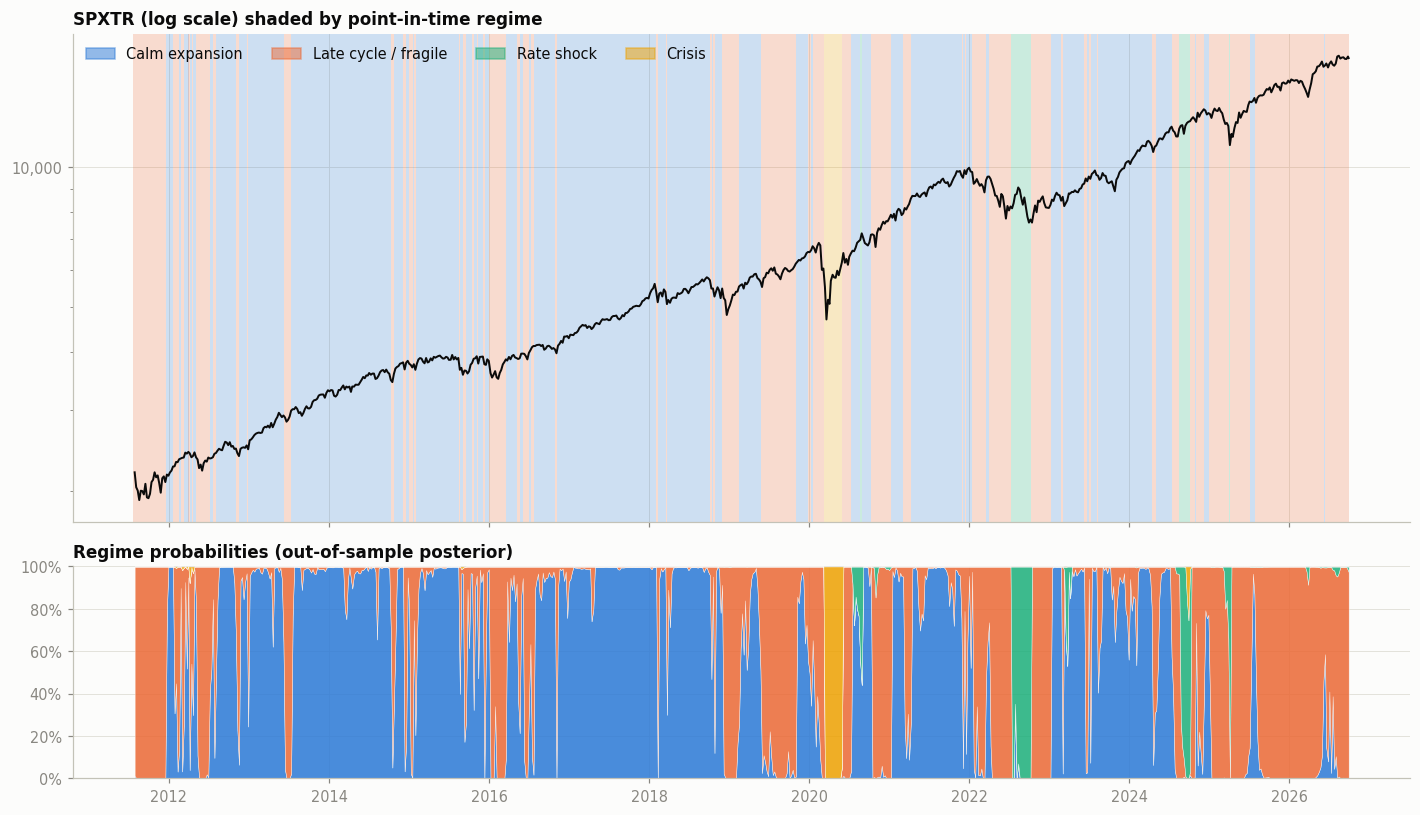

In [31]:
def spans(s):
    """Contiguous (start, end, value) spans of a weekly categorical series."""
    grp = (s != s.shift()).cumsum()
    out = []
    for _, g in s.groupby(grp):
        out.append((g.index[0] - pd.Timedelta(days=6), g.index[-1] + pd.Timedelta(days=1), g.iloc[0]))
    return out


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True, gridspec_kw={'height_ratios': [3, 1.3]})
px_oos = weekly_px.loc[regime.index[0]:]
for a, b, r in spans(regime):
    ax1.axvspan(a, b, color=COLORS[r], alpha=0.22, lw=0)
ax1.plot(px_oos.index, px_oos, color=INK, lw=1.3)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())
ax1.set_title('SPXTR (log scale) shaded by point-in-time regime')
ax1.legend(handles=[Patch(color=COLORS[n], alpha=0.5, label=n) for n in ORDER], ncol=len(ORDER), loc='upper left')

ax2.stackplot(probs_named.index, probs_named.T.values, colors=[COLORS[n] for n in ORDER], alpha=0.85,
              edgecolor=SURFACE, linewidth=0.3)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax2.set_title('Regime probabilities (out-of-sample posterior)')
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

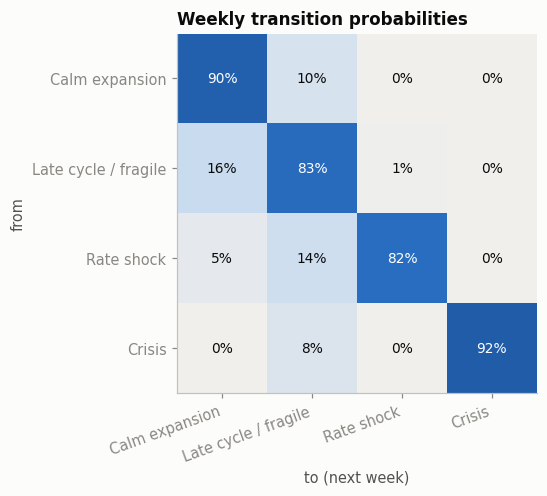

,spells,avg_weeks,max_weeks
regime,,,
Calm expansion,48,9.600,65.000
Late cycle / fragile,52,5.700,45.000
Rate shock,4,5.500,13.000
Crisis,1,12.000,12.000


In [32]:
# Regime persistence: weekly transition matrix and spell lengths
trans = pd.crosstab(regime.shift().rename('from'), regime.rename('to'), normalize='index').reindex(index=ORDER, columns=ORDER)
spell = pd.DataFrame([(r, (b - a).days / 7) for a, b, r in spans(regime)], columns=['regime', 'weeks'])
spell_stats = spell.groupby('regime')['weeks'].agg(spells='count', avg_weeks='mean', max_weeks='max').reindex(ORDER)

fig, ax = plt.subplots(figsize=(6.2, 4.6))
im = ax.imshow(trans.values, cmap=SEQUENTIAL, vmin=0, vmax=1)
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        v = trans.values[i, j]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9, color='white' if v > 0.6 else INK)
ax.set_xticks(range(len(ORDER)), ORDER, rotation=20, ha='right')
ax.set_yticks(range(len(ORDER)), ORDER)
ax.set_xlabel('to (next week)')
ax.set_ylabel('from')
ax.grid(False)
ax.set_title('Weekly transition probabilities')
fig.tight_layout()
plt.show()
spell_stats.round(1)

In [33]:
# Every spell of the rare regimes (dates = first / last classified week)
grp = (regime != regime.shift()).cumsum()
episodes = (regime.to_frame().assign(date=regime.index).groupby(grp)
            .agg(regime=('regime', 'first'), start=('date', 'first'), end=('date', 'last'), weeks=('date', 'size')))
episodes[episodes.regime.isin(['Rate shock', 'Crisis'])].reset_index(drop=True)

,regime,start,end,weeks
0,Crisis,2020-03-13,2020-05-29,12
1,Rate shock,2020-08-28,2020-08-28,1
2,Rate shock,2022-07-15,2022-10-07,13
3,Rate shock,2024-08-23,2024-10-04,7
4,Rate shock,2025-04-04,2025-04-04,1


## 7. Economic profile of each regime

Mean and standard deviation of every variable within each (out-of-sample) regime. Two views:

* **Model features** (what the GMM saw), and
* **Raw levels of every series in the file** — including the short-history series that could not be model inputs
  (`tlt_vol_bp`, `wti`, `vixeq`, `tips_30y`; their statistics use only the weeks where they exist — see `n`).

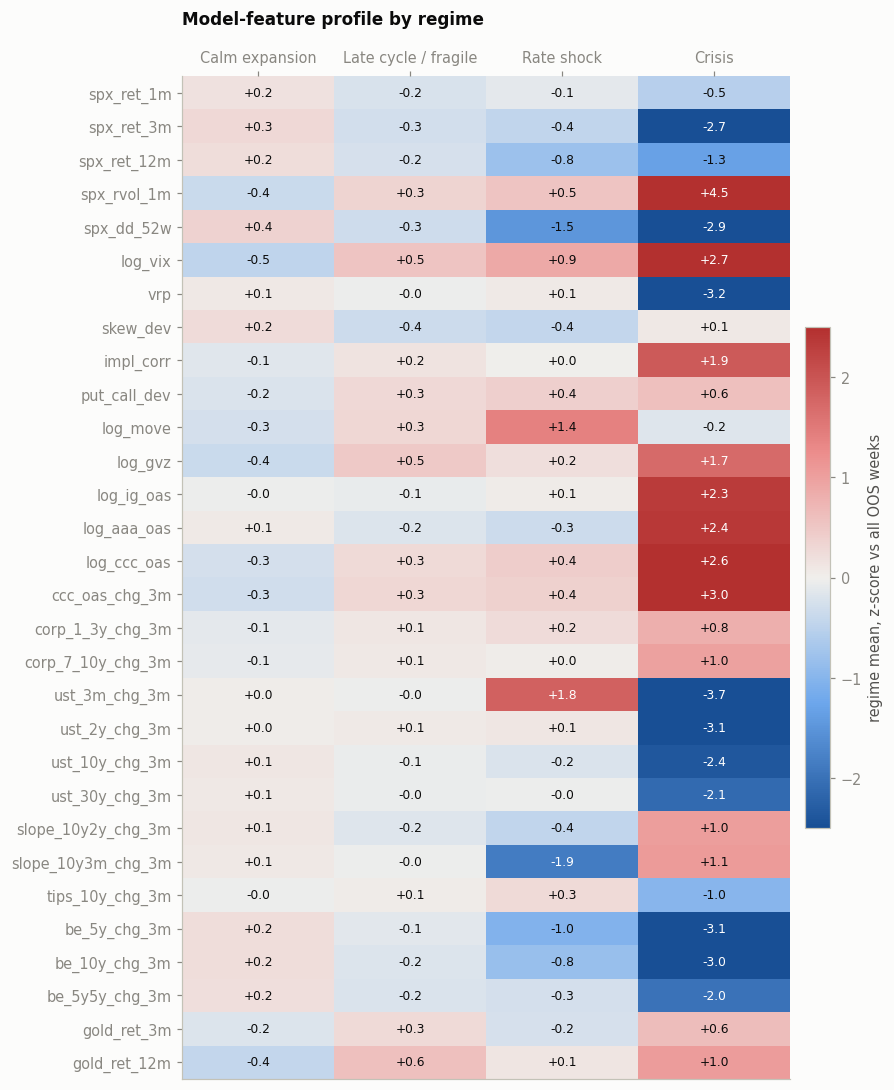

In [34]:
feat_stats = Xp.groupby(regime).agg(['mean', 'std']).T.unstack(level=1)
feat_stats = feat_stats.reindex(columns=pd.MultiIndex.from_product([ORDER, ['mean', 'std']]))

# heatmap: regime means standardised by the (OOS-period) cross-regime S.D. of each feature — display only
z = (prof.rename(index=names).reindex(ORDER) - Xp.mean()) / Xp.std()
fig, ax = plt.subplots(figsize=(8.5, 10))
im = ax.imshow(z.T.values, cmap=DIVERGING, vmin=-2.5, vmax=2.5, aspect='auto')
for i in range(z.shape[1]):
    for j in range(z.shape[0]):
        v = z.values[j, i]
        ax.text(j, i, f'{v:+.1f}', ha='center', va='center', fontsize=8, color='white' if abs(v) > 1.6 else INK)
ax.set_xticks(range(len(ORDER)), ORDER)
ax.xaxis.tick_top()
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
cb.set_label('regime mean, z-score vs all OOS weeks')
ax.set_title('Model-feature profile by regime', pad=34)
fig.tight_layout()
plt.show()

In [35]:
pd.options.display.float_format = '{:,.3f}'.format
feat_stats

Calm expansion        Late cycle / fragile        Rate shock        Crisis      
                             mean    std                 mean    std       mean    std   mean   std
spx_ret_1m                  0.019  0.028                0.003  0.048      0.008  0.070 -0.011 0.160
spx_ret_3m                  0.054  0.045                0.018  0.072      0.008  0.074 -0.140 0.078
spx_ret_12m                 0.178  0.104                0.120  0.133      0.051  0.193 -0.015 0.079
spx_rvol_1m                 0.113  0.044                0.179  0.084      0.197  0.054  0.568 0.290
spx_dd_52w                 -0.018  0.025               -0.051  0.054     -0.109  0.086 -0.181 0.065
log_vix                     2.685  0.230                3.002  0.282      3.114  0.266  3.691 0.319
vrp                         0.038  0.034                0.031  0.060      0.036  0.046 -0.148 0.191
skew_dev                    3.171  8.713               -2.448  9.240     -3.007 13.557  1.725 5.307
impl_corr                  30.574 12.437               35.703 21.261     33.219 14.389 65.738 7.747
put_call_dev               -0.029  0.096                0.026  0.123      0.039  0.122  0.062 0.146
log_move                    4.227  0.288                4.397  0.272      4.726  0.233  4.256 0.351
log_gvz                     2.716  0.236                2.956  0.278      2.875  0.110  3.303 0.238
log_ig_oas                  0.222  0.211                0.208  0.359      0.243  0.223  0.900 0.205
log_aaa_oas                -0.518  0.217               -0.590  0.351     -0.639  0.268  0.151 0.221
log_ccc_oas                 2.184  0.215                2.310  0.223      2.344  0.136  2.857 0.059
ccc_oas_chg_3m             -0.050  0.128                0.058  0.190      0.071  0.184  0.542 0.092
corp_1_3y_chg_3m            0.007  0.341                0.107  0.594      0.170  0.863  0.446 0.756
corp_7_10y_chg_3m          -0.018  0.404                0.063  0.538      0.037  0.558  0.482 0.482
ust_3m_chg_3m               0.071  0.175                0.052  0.415      0.792  1.036 -1.406 0.118
ust_2y_chg_3m               0.084  0.264                0.093  0.486      0.110  0.903 -1.215 0.175
ust_10y_chg_3m              0.077  0.329                0.008  0.487     -0.053  0.487 -0.966 0.215
ust_30y_chg_3m              0.053  0.317                0.006  0.447      0.012  0.357 -0.786 0.246
slope_10y2y_chg_3m         -0.007  0.255               -0.086  0.291     -0.163  0.488  0.249 0.078
slope_10y3m_chg_3m          0.006  0.369               -0.044  0.453     -0.845  0.750  0.440 0.168
tips_10y_chg_3m             0.025  0.290                0.050  0.415      0.126  0.507 -0.314 0.270
be_5y_chg_3m                0.071  0.250               -0.036  0.297     -0.314  0.335 -0.941 0.208
be_10y_chg_3m               0.051  0.188               -0.042  0.221     -0.186  0.230 -0.667 0.221
be_5y5y_chg_3m              0.032  0.174               -0.048  0.203     -0.059  0.157 -0.394 0.243
gold_ret_3m                 0.003  0.065                0.038  0.092     -0.002  0.097  0.066 0.026
gold_ret_12m                0.007  0.128                0.178  0.174      0.098  0.170  0.255 0.056

In [36]:
# Raw levels of every series in the file (sampled weekly, point-in-time daily frame)
lv = daily.resample('W-FRI').last().set_axis(weekly.index)
levels = pd.DataFrame(index=lv.index)
levels['SPXTR 12m return (%)'] = F['spx_ret_12m'].resample('W-FRI').last().values * 100
levels['SPXTR 1m realised vol (%)'] = F['spx_rvol_1m'].resample('W-FRI').last().values * 100
levels['SPXTR drawdown from 52w high (%)'] = F['spx_dd_52w'].resample('W-FRI').last().values * 100
levels['VIX'] = lv['vix']
levels['VIXEQ (constituent vol)'] = lv['vixeq']
levels['Implied correlation (1m)'] = lv['impl_corr']
levels['SKEW'] = lv['skew']
levels['Equity put/call'] = lv['put_call']
levels['MOVE (bond vol)'] = lv['move']
levels['TLT vol (bp)'] = lv['tlt_vol_bp']
levels['GVZ (gold vol)'] = lv['gvz']
levels['IG OAS (bp)'] = lv['ig_oas'] * 100
levels['AAA OAS (bp)'] = lv['aaa_oas'] * 100
levels['CCC OAS (bp)'] = lv['ccc_oas'] * 100
levels['Corp 1-3y yield (%)'] = lv['corp_1_3y']
levels['Corp 7-10y yield (%)'] = lv['corp_7_10y']
levels['UST 3m (%)'] = lv['ust_3m']
levels['UST 2y (%)'] = lv['ust_2y']
levels['UST 10y (%)'] = lv['ust_10y']
levels['UST 30y (%)'] = lv['ust_30y']
levels['10y-2y slope (bp)'] = (lv['ust_10y'] - lv['ust_2y']) * 100
levels['10y-3m slope (bp)'] = (lv['ust_10y'] - lv['ust_3m']) * 100
levels['UST 2y 3m change (bp)'] = X['ust_2y_chg_3m'].reindex(lv.index) * 100
levels['10y TIPS real yield (%)'] = lv['tips_10y']
levels['30y TIPS real yield (%)'] = lv['tips_30y']
levels['5y breakeven (%)'] = lv['be_5y']
levels['10y breakeven (%)'] = lv['be_10y']
levels['5y5y fwd inflation (%)'] = lv['be_5y5y']
levels['Real policy rate: 3m − 5y BE (%)'] = lv['ust_3m'] - lv['be_5y']
levels['Gold 12m return (%)'] = (lv['gold'] / lv['gold'].shift(52) - 1) * 100
levels['WTI crude ($)'] = lv['wti']
levels['WTI 3m return (%)'] = (lv['wti'] / lv['wti'].shift(13) - 1) * 100
levels = levels.loc[regime.index]

level_stats = levels.groupby(regime).agg(['mean', 'std', 'count']).T.unstack(level=1)
level_stats = level_stats.reindex(columns=pd.MultiIndex.from_product([ORDER, ['mean', 'std', 'count']]))
level_stats = level_stats.rename(columns={'std': 'sd', 'count': 'n'}, level=1)
level_stats.style.format('{:,.2f}').format('{:,.0f}', subset=pd.IndexSlice[:, pd.IndexSlice[:, 'n']])

## 8. Forward SPXTR returns by regime (out-of-sample)

For every week classified point-in-time, the forward SPXTR return from that week's close. Statistics per regime:
mean, median, S.D., hit rate (% positive), mean return annualised, and a **Newey-West (HAC) t-stat of the difference
vs. all other weeks** (lags = horizon, because overlapping forward windows are autocorrelated). `episodes` = number of
distinct regime spells — the effective number of independent observations is closer to this than to `weeks`.

In [37]:
fwd_oos = fwd.loc[regime.index]


def hac_tstat(y, dummy, lags):
    m = y.notna()
    res = sm.OLS(y[m], sm.add_constant(dummy[m].astype(float))).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return res.tvalues.iloc[1]


rows = []
for h, n in HORIZONS.items():
    y = fwd_oos[h]
    for r in ORDER + ['All weeks']:
        sel = y if r == 'All weeks' else y[regime == r]
        sel = sel.dropna()
        rows.append({
            'horizon': h, 'regime': r, 'weeks': len(sel),
            'episodes': len(spell[spell.regime == r]) if r != 'All weeks' else np.nan,
            'mean': sel.mean(), 'median': sel.median(), 'std': sel.std(),
            'hit_rate': (sel > 0).mean(), 'p10': sel.quantile(0.1), 'p90': sel.quantile(0.9),
            'mean_annualised': (1 + sel.mean()) ** (52 / n) - 1,
            't_vs_rest (HAC)': hac_tstat(y, regime == r, n) if r != 'All weeks' else np.nan,
        })
fwd_table = pd.DataFrame(rows).set_index(['horizon', 'regime'])
fwd_table.style.format({
    'weeks': '{:.0f}', 'episodes': '{:.0f}', 'mean': '{:.2%}', 'median': '{:.2%}', 'std': '{:.2%}',
    'hit_rate': '{:.0%}', 'p10': '{:.1%}', 'p90': '{:.1%}', 'mean_annualised': '{:.1%}', 't_vs_rest (HAC)': '{:+.2f}',
}, na_rep='')

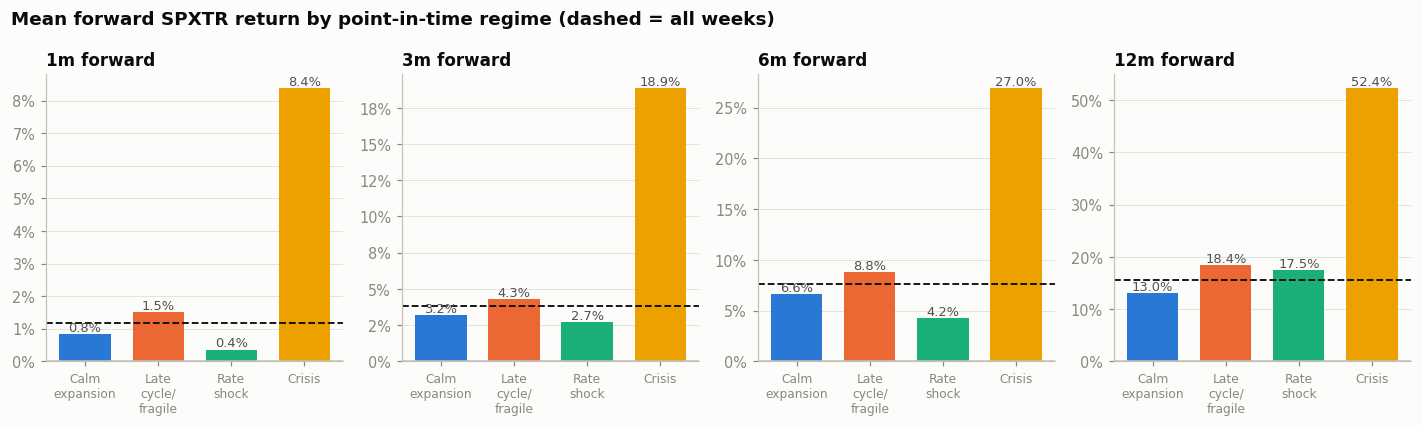

In [38]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(13, 3.9))
for ax, h in zip(axes, HORIZONS):
    vals = [fwd_table.loc[(h, r), 'mean'] * 100 for r in ORDER]
    ax.bar(range(len(ORDER)), vals, color=[COLORS[r] for r in ORDER], width=0.7)
    ax.axhline(fwd_table.loc[(h, 'All weeks'), 'mean'] * 100, color=INK, lw=1.2, ls='--')
    ax.axhline(0, color=AXIS, lw=1)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8.5, color=INK_2)
    ax.set_xticks(range(len(ORDER)), [r.replace(' / ', '/\n').replace(' ', '\n') for r in ORDER], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_title(f'{h} forward')
    ax.grid(axis='x', visible=False)
fig.suptitle('Mean forward SPXTR return by point-in-time regime (dashed = all weeks)', x=0.01, ha='left',
             fontsize=12, fontweight='semibold')
fig.tight_layout()
plt.show()

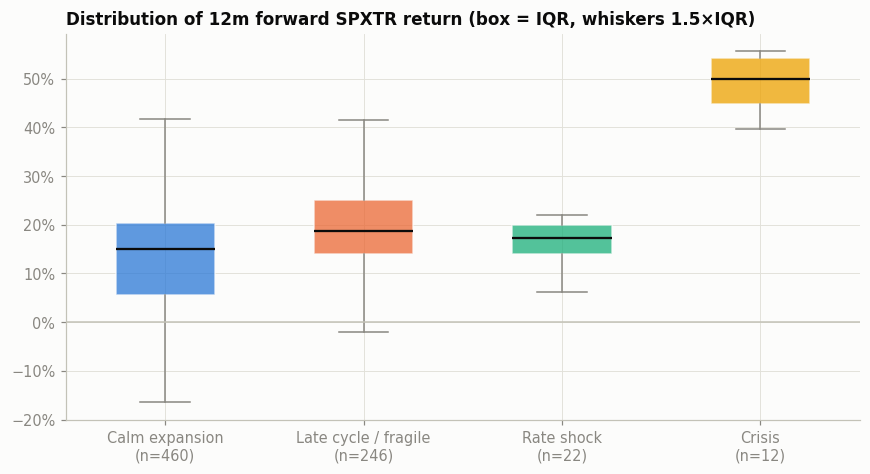

In [39]:
fig, ax = plt.subplots(figsize=(8, 4.4))
data12 = [fwd_oos.loc[regime == r, '12m'].dropna() * 100 for r in ORDER]
bp = ax.boxplot(data12, widths=0.5, patch_artist=True, showfliers=False,
                medianprops={'color': INK, 'lw': 1.5}, whiskerprops={'color': MUTED}, capprops={'color': MUTED})
for patch, r in zip(bp['boxes'], ORDER):
    patch.set_facecolor(COLORS[r]); patch.set_alpha(0.75); patch.set_edgecolor(SURFACE)
ax.axhline(0, color=AXIS, lw=1)
ax.set_xticks(range(1, len(ORDER) + 1), [f'{r}\n(n={len(d)})' for r, d in zip(ORDER, data12)])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_title('Distribution of 12m forward SPXTR return (box = IQR, whiskers 1.5×IQR)')
fig.tight_layout()
plt.show()

## 9. Robustness

**(a) How much does look-ahead flatter the result?** The same pipeline fit **once on the full sample** (every label
is informed by the future) — shown only as a contrast, *not* as a result.

**(b) Sensitivity to K.** Point-in-time forward returns for K−1 and K+1: are the conclusions an artefact of K?

In [40]:
full_model = make_model(K).fit(X)
lab_full = pd.Series(full_model.predict(X), index=X.index)
# map full-sample labels to PIT names by maximum overlap over the OOS period
agree = pd.crosstab(lab_full.loc[regime.index], regime).reindex(columns=ORDER, fill_value=0)
r_, c_ = linear_sum_assignment(-agree.values)
full_names = {agree.index[i]: ORDER[j] for i, j in zip(r_, c_)}
regime_full = lab_full.map(full_names)
print(f'Agreement of full-sample (look-ahead) labels with point-in-time labels over the OOS period: '
      f'{(regime_full.loc[regime.index] == regime).mean():.1%}')

cmp = pd.concat({
    'point-in-time (OOS)': fwd_oos.groupby(regime).mean(),
    'full-sample fit, same weeks (look-ahead)': fwd.loc[regime.index].groupby(regime_full.loc[regime.index]).mean(),
    'full-sample fit, 2008-2026 (look-ahead)': fwd.groupby(regime_full).mean(),
}, axis=1).reindex(ORDER)
cmp.style.format('{:.2%}')

Agreement of full-sample (look-ahead) labels with point-in-time labels over the OOS period: 47.7%


In [41]:
sens = {}
for k_alt in sorted({2, K - 1, K + 1} - {K, 1}):
    lab_alt, _, _ = walk_forward(X, k_alt)
    g = fwd.loc[lab_alt.index].groupby(lab_alt)
    t = g.mean().join(g.size().rename('weeks'))
    t['avg VIX'] = levels['VIX'].reindex(lab_alt.index).groupby(lab_alt).mean()
    t['avg IG OAS (bp)'] = levels['IG OAS (bp)'].reindex(lab_alt.index).groupby(lab_alt).mean()
    t['avg Δ3m UST 2y (bp)'] = levels['UST 2y 3m change (bp)'].reindex(lab_alt.index).groupby(lab_alt).mean()
    sens[f'K={k_alt}'] = t.sort_values('avg VIX')
sens_df = pd.concat(sens)
sens_df.style.format({**{h: '{:.2%}' for h in HORIZONS}, 'weeks': '{:.0f}', 'avg VIX': '{:.1f}',
                      'avg IG OAS (bp)': '{:.0f}', 'avg Δ3m UST 2y (bp)': '{:+.0f}'})

In [42]:
# Current regime (latest point-in-time classification)
latest = probs_named.iloc[-1]
print(f'Latest week: {probs_named.index[-1].date()}  →  {regime.iloc[-1]}')
latest.to_frame('probability').style.format('{:.1%}')

Latest week: 2026-09-28  →  Late cycle / fragile


,probability
Calm expansion,0.0%
Late cycle / fragile,97.4%
Rate shock,2.6%
Crisis,0.0%


## 10. Enhancement: Kalman filter

Two places where noise can hurt a GMM regime model, and a (causal) Kalman filter for each:

1. **Noisy inputs** — weekly features such as 1m returns, the variance risk premium or put/call deviations are noisy;
   single-week spikes can flip the regime. Each feature is filtered with a **local-level model**
   (`x_t = μ_t + ε_t`, `μ_t = μ_{t-1} + η_t`) and the GMM is fed the filtered level `μ_t|t`.
2. **Noisy classifications** — the posterior regime probabilities can whipsaw week to week. Each regime's probability
   series is filtered with the same local-level model, then re-normalised to sum to one.

**Point-in-time rules for the filter**

* Only the **forward filter** (`μ_t|t`, uses data up to *t*) is used — never the RTS *smoother*, which uses future data.
* The signal-to-noise ratio `q = Var(η)/Var(ε)` of each series is estimated by **maximum likelihood on the training
  window of each quarterly re-fit** (grid search over q), so parameters are also point-in-time.
* A large `q` means "the series is mostly signal" (steady-state Kalman gain → 1, no smoothing); a small `q` means heavy smoothing.

**Variants compared (all with the same K = 4 and walk-forward schedule):** baseline, KF on features, KF on
probabilities, KF on both. Each variant's regimes are named by **maximum overlap with the baseline regimes**
(Hungarian matching), so a column like "Rate shock" means the same thing across variants.

**What counts as "better"** (forward returns are used for *evaluation only*, never to tune the filter):

* **Persistence** — fewer regime switches and 1-week "blips" (a regime that flips every other week is not tradable).
* **Stability** — agreement of labels between consecutive re-fits.
* **Economic separation** — HAC Wald test that forward returns differ across regimes; between-regime R².
* **Out-of-sample predictive R²** (Campbell–Thompson): at each week, predict the forward return with the historical
  average forward return *of the current regime*, using only past weeks whose forward window has already closed; compare
  with the historical unconditional average. R² > 0 ⇒ the regime label carries usable information.
* **Detection lag** — a filter smooths but also delays; how late does it flag COVID and the 2022 rate shock?

In [43]:
Q_GRID = np.logspace(-3, 3, 61)   # candidate signal-to-noise ratios


def local_level_filter(Y, q):
    """Causal local-level Kalman filter (in units of the observation variance), vectorised over columns / q-grid.

    Y: (T, N) observations; q: array broadcastable to (N,) or (G, N).
    Returns filtered states μ_t|t with shape (T, *broadcast) and the concentrated log-likelihood.
    """
    Y = np.asarray(Y, dtype=float)
    q = np.asarray(q, dtype=float)
    shape = np.broadcast(Y[0], q).shape
    a = np.broadcast_to(Y[0], shape).copy()   # diffuse prior updated with the first observation
    P = np.ones(shape)
    states = np.empty((len(Y),) + shape)
    states[0] = a
    sum_log_f, sum_v2_f = np.zeros(shape), np.zeros(shape)
    for t in range(1, len(Y)):
        P_pred = P + q
        F = P_pred + 1.0
        v = Y[t] - a
        gain = P_pred / F
        a = a + gain * v
        P = P_pred * (1 - gain)
        states[t] = a
        sum_log_f += np.log(F)
        sum_v2_f += v * v / F
    n = len(Y) - 1
    loglik = -0.5 * (sum_log_f + n * np.log(sum_v2_f / n + 1e-12))
    return states, loglik


def fit_q(Y):
    """MLE of the signal-to-noise ratio q for each column of Y (grid search)."""
    _, ll = local_level_filter(Y, Q_GRID[:, None])
    return Q_GRID[ll.argmax(axis=0)]


def steady_state_gain(q):
    return (-q + np.sqrt(q ** 2 + 4 * q)) / 2


def kf_feature_filter(X_upto, n_train):
    """Filter every feature; q estimated on the training rows only."""
    q = fit_q(X_upto.values[:n_train])
    states, _ = local_level_filter(X_upto.values, q)
    return pd.DataFrame(states, index=X_upto.index, columns=X_upto.columns)


def kf_prob_filter(p_train, p_test):
    """Filter regime probabilities; q estimated on the training-period posteriors; re-normalise."""
    q = fit_q(p_train)
    states, _ = local_level_filter(np.vstack([p_train, p_test]), q)
    out = np.clip(states[len(p_train):], 0, None)
    return out / out.sum(axis=1, keepdims=True)


# Kalman parameters at the most recent re-fit (descriptive)
q_last = fit_q(X.values)
kf_params = pd.DataFrame({'q (signal/noise)': q_last, 'steady-state gain': steady_state_gain(q_last)}, index=FEATURES)
kf_params.sort_values('steady-state gain').style.format('{:.3f}').bar(subset=['steady-state gain'], color='#9ec5f4', vmin=0, vmax=1)

,q (signal/noise),steady-state gain
skew_dev,0.631,0.539
log_vix,3.162,0.798
slope_10y2y_chg_3m,3.981,0.828
spx_ret_12m,5.012,0.854
be_5y5y_chg_3m,5.012,0.854
log_gvz,6.310,0.878
spx_ret_3m,10.000,0.916
tips_10y_chg_3m,10.000,0.916
be_5y_chg_3m,10.000,0.916
vrp,12.589,0.931


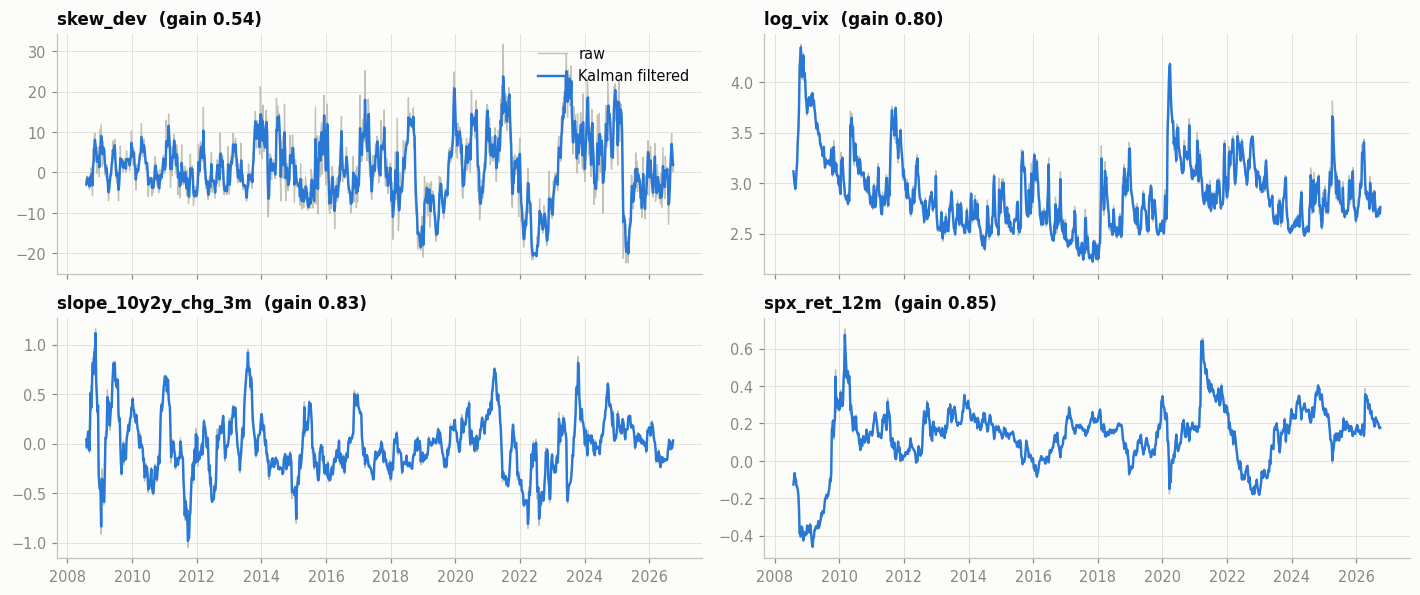

In [44]:
# Illustration: raw vs Kalman-filtered (causal) inputs for a few of the noisiest features
illus = kf_params['steady-state gain'].nsmallest(4).index
X_kf_full = kf_feature_filter(X, len(X))
fig, axes = plt.subplots(2, 2, figsize=(13, 5.5), sharex=True)
for ax, c in zip(axes.flat, illus):
    ax.plot(X.index, X[c], color=AXIS, lw=0.9, label='raw')
    ax.plot(X.index, X_kf_full[c], color=SERIES[0], lw=1.6, label='Kalman filtered')
    ax.set_title(f'{c}  (gain {kf_params.loc[c, "steady-state gain"]:.2f})')
axes[0, 0].legend(loc='upper right')
fig.tight_layout()
plt.show()

In [45]:
VARIANTS = {
    'Baseline': {},
    'KF features': {'feature_filter': kf_feature_filter},
    'KF probabilities': {'prob_filter': kf_prob_filter},
    'KF both': {'feature_filter': kf_feature_filter, 'prob_filter': kf_prob_filter},
}
variant_regime, variant_probs, variant_log = {}, {}, {}
for v, kw in VARIANTS.items():
    if v == 'Baseline':
        lab, pr, lg = labels_pit, probs_pit, refit_log
    else:
        lab, pr, lg = walk_forward(X, K, **kw)
    if v == 'Baseline':
        nm = names
    else:                              # match to baseline regimes by maximum overlap
        ct = pd.crosstab(lab, regime.reindex(lab.index)).reindex(columns=ORDER, fill_value=0)
        r_, c_ = linear_sum_assignment(-ct.values)
        nm = {ct.index[i]: ORDER[j] for i, j in zip(r_, c_)}
    variant_regime[v] = lab.map(nm).rename('regime')
    variant_probs[v] = pr.rename(columns=nm).reindex(columns=ORDER)
    variant_log[v] = lg
    print(f'{v:17s} regime shares: ' + ', '.join(f'{r} {(variant_regime[v] == r).mean():.1%}' for r in ORDER))

Baseline          regime shares: Calm expansion 58.1%, Late cycle / fragile 37.6%, Rate shock 2.8%, Crisis 1.5%
KF features       regime shares: Calm expansion 59.6%, Late cycle / fragile 38.1%, Rate shock 0.4%, Crisis 1.9%
KF probabilities  regime shares: Calm expansion 58.5%, Late cycle / fragile 37.2%, Rate shock 2.8%, Crisis 1.5%
KF both           regime shares: Calm expansion 59.6%, Late cycle / fragile 38.1%, Rate shock 0.4%, Crisis 1.9%


In [46]:
def oos_r2(reg, y, n, min_obs=13):
    """Campbell-Thompson OOS R² of the regime-conditional historical mean vs the unconditional historical mean.
    Week j's forward window closes after week j+n, so at week i only weeks j <= i-n-1 are usable."""
    yv, rv = y.reindex(reg.index).values, reg.values
    pred_c, pred_u, act = [], [], []
    for i in range(len(yv)):
        if np.isnan(yv[i]) or i - n <= 0:
            continue
        yp, rp = yv[:i - n], rv[:i - n]
        ok = ~np.isnan(yp)
        if ok.sum() < min_obs:
            continue
        u = yp[ok].mean()
        same = ok & (rp == rv[i])
        pred_c.append(yp[same].mean() if same.sum() >= min_obs else u)
        pred_u.append(u)
        act.append(yv[i])
    act, pred_c, pred_u = map(np.array, (act, pred_c, pred_u))
    return 1 - ((act - pred_c) ** 2).sum() / ((act - pred_u) ** 2).sum()


def separation(reg, y, n):
    """HAC Wald p-value that all regime means are equal, and between-regime R²."""
    m = y.reindex(reg.index).notna()
    D = pd.get_dummies(reg[m]).astype(float)
    D = D.drop(columns=D.columns[0])
    res = sm.OLS(y.reindex(reg.index)[m], sm.add_constant(D)).fit(cov_type='HAC', cov_kwds={'maxlags': n})
    R = np.zeros((D.shape[1], D.shape[1] + 1))
    R[:, 1:] = np.eye(D.shape[1])
    return float(res.wald_test(R, use_f=True, scalar=True).pvalue), res.rsquared


def first_week(reg, name, start, end):
    s = reg.loc[start:end]
    s = s[s == name]
    return s.index[0].date() if len(s) else None


diag = {}
for v, reg in variant_regime.items():
    run_id = (reg != reg.shift()).cumsum()
    spell_len = reg.groupby(run_id).size()
    years = (reg.index[-1] - reg.index[0]).days / 365.25
    d = {
        'switches / year': (len(spell_len) - 1) / years,
        'avg spell (weeks)': spell_len.mean(),
        '1-week blips (% of spells)': (spell_len == 1).mean(),
        're-fit label agreement (median)': variant_log[v]['agreement_with_prev'].median(),
        're-fit label agreement (min)': variant_log[v]['agreement_with_prev'].min(),
        'agreement with baseline': (reg == variant_regime['Baseline']).mean(),
    }
    for h in ['3m', '12m']:
        n = HORIZONS[h]
        p, r2 = separation(reg, fwd[h], n)
        d[f'{h}: Wald p-value (HAC)'] = p
        d[f'{h}: between-regime R²'] = r2
        d[f'{h}: OOS predictive R²'] = oos_r2(reg, fwd[h], n)
    d['COVID: first Crisis week'] = first_week(reg, 'Crisis', '2020-02-01', '2020-06-30')
    d['2022: first Rate-shock week'] = first_week(reg, 'Rate shock', '2022-01-01', '2022-12-31')
    diag[v] = d
kf_diag = pd.DataFrame(diag)
kf_diag

,Baseline,KF features,KF probabilities,KF both
switches / year,6.857,6.000,6.329,6.000
avg spell (weeks),7.552,8.620,8.175,8.620
1-week blips (% of spells),0.286,0.250,0.268,0.261
re-fit label agreement (median),0.918,0.937,0.918,0.937
re-fit label agreement (min),0.533,0.619,0.533,0.619
agreement with baseline,1.000,0.887,0.989,0.887
3m: Wald p-value (HAC),0.000,0.000,0.000,0.000
3m: between-regime R²,0.092,0.087,0.094,0.086
3m: OOS predictive R²,-0.035,-0.041,-0.033,-0.041
12m: Wald p-value (HAC),0.000,0.000,0.000,0.000


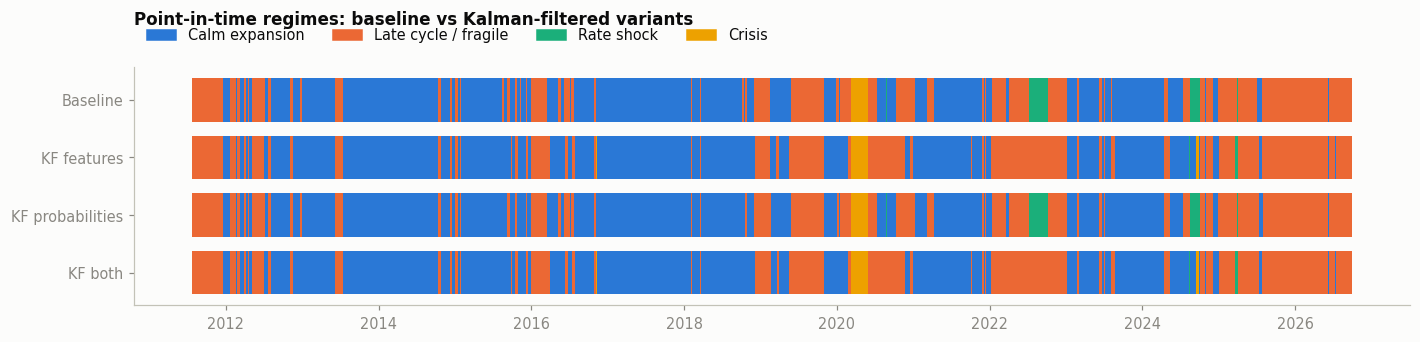

In [47]:
fig, ax = plt.subplots(figsize=(13, 3.2))
for i, (v, reg) in enumerate(variant_regime.items()):
    for a, b, r in spans(reg):
        ax.broken_barh([(mdates.date2num(a), mdates.date2num(b) - mdates.date2num(a))], (i - 0.38, 0.76),
                       color=COLORS[r], lw=0)
ax.set_yticks(range(len(variant_regime)), list(variant_regime))
ax.invert_yaxis()
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(False)
ax.legend(handles=[Patch(color=COLORS[n], label=n) for n in ORDER], ncol=len(ORDER), loc='upper left',
          bbox_to_anchor=(0, 1.22))
ax.set_title('Point-in-time regimes: baseline vs Kalman-filtered variants', pad=28)
fig.tight_layout()
plt.show()

In [48]:
# Forward SPXTR returns by regime for each variant
rows = []
for v, reg in variant_regime.items():
    for r in ORDER:
        sel = fwd.loc[reg.index][reg == r]
        rows.append({'variant': v, 'regime': r, 'weeks': (reg == r).sum(),
                     'spells': ((reg == r) & (reg != reg.shift())).sum(),
                     **{f'{h} mean': sel[h].mean() for h in HORIZONS}})
kf_fwd = pd.DataFrame(rows).set_index(['variant', 'regime'])
kf_fwd.style.format({'weeks': '{:.0f}', 'spells': '{:.0f}', **{f'{h} mean': '{:.2%}' for h in HORIZONS}}, na_rep='–')

### Kalman filter verdict

* **Most inputs are already smooth.** MLE puts the steady-state gain at ≥ 0.9 for 24 of 30 features (≈ 0.999 for
  spreads, realised vol, rate changes — i.e. essentially no filtering). Only SKEW deviation (0.54), VIX (0.80), the
  curve-slope change and 12m return get meaningful smoothing — the inputs are 3-month changes / levels that already
  average out weekly noise.
* **KF on features — not an improvement.** Regimes become slightly more persistent (6.9 → 6.0 switches a year) and
  re-fits more consistent, but the filter's lag erases the **Rate shock** regime (22 → 3 weeks; the 2022 shock is
  never flagged) and the information content falls: 12m between-regime R² 0.18 → 0.16 and OOS predictive R²
  +2.8% → −0.7%.
* **KF on probabilities — a small, free improvement in persistence.** Fewer switches (6.9 → 6.3 a year) and blips
  with 99% agreement with the baseline, no detection delay (COVID flagged on 13-Mar-2020, 2022 shock on 15-Jul-2022)
  and unchanged information (OOS R² +2.8%). Useful if the labels drive trading (lower turnover), but it does not change
  any conclusion.
* **Net:** the Kalman filter does not materially improve the regime model; the baseline is kept for the rest of the
  notebook. The larger lesson is in the OOS predictive R²: regime labels add a little information about the **12-month**
  forward return (+2.8%) but **none about the 3-month** return (−3.5%, worse than the historical mean) — regimes describe
  the environment well; they are a weak short-term timing signal.

## 11. S&P 500 sector forward returns by regime

S&P 500 GICS sector **total-return** indices. The sector history starts in **Sep-2012** (Real Estate Sep-2016,
Equal Weight Jul-2023), so only regime weeks from those dates onward are used — see `n` in every table.
Forward returns use the same convention as SPXTR (entry at the next trading day's close after the classification week).
**Excess** = sector forward return − SPXTR forward return over the same window.
**Regime tilt** = a sector's excess return in a regime minus its average excess return over all weeks — this removes
the sector's secular trend over 2012-2026 (e.g. Information Technology beat the index in almost every regime) and
isolates what the *regime* adds.

t-stats (HAC, lags = horizon) are shown only when a regime has at least 3× the horizon in weeks; for the rare regimes
(Rate shock ≈ 22 weeks, Crisis = COVID only) the numbers are descriptive of 2-3 episodes, not statistical evidence.

In [49]:
SECTOR_FILE = ROOT / 'data/tradingview/stock_index/us_sector_index_tr.csv'
sec_raw = pd.read_csv(SECTOR_FILE)
sec_raw['date'] = to_date(sec_raw['time'])
sec_raw = sec_raw.drop(columns='time').set_index('date').sort_index()
sec_raw = sec_raw[~sec_raw.index.duplicated(keep='last')]

sector_map = {}
for c in sec_raw.columns:
    m = re.match(r'S&P 500 (.+?) Total Return', c)
    if m:
        name = m.group(1)
        sector_map[c] = 'Equal Weight (RSP-TR)' if name.upper() == 'EQUAL WEIGHTED' else name
sectors = sec_raw[list(sector_map)].rename(columns=sector_map).ffill(limit=5)
SECTORS = list(sectors.columns)

# sanity check: the file's `close` is SPXTR, the same series as the regime file
common = sec_raw.index.intersection(px.dropna().index)
print(f'Max |close − SPXTR| on common dates: {(sec_raw.loc[common, "close"] / px.loc[common] - 1).abs().max():.2e}')
pd.DataFrame({'first': sectors.apply(lambda c: c.first_valid_index()).dt.date, 'obs': sectors.count()})

Max |close − SPXTR| on common dates: 0.00e+00


,first,obs
Materials,2012-09-25,3521
Utilities,2012-09-25,3521
Financials,2012-09-25,3521
Health Care,2012-09-25,3521
Industrials,2012-09-25,3521
Real Estate,2016-09-19,2520
Energy,2012-09-25,3521
Communication Services,2012-09-25,3521
Information Technology,2012-09-25,3521
Consumer Staples,2012-09-25,3521


In [50]:
# Weekly entry price = close of the next trading day after each classification week (bins aligned with `weekly`)
sec_entry = (sectors.shift(-1).resample('W-FRI').last()
             .reindex(week_end.index).set_axis(weekly.index))
sec_fwd = {h: sec_entry.shift(-n) / sec_entry - 1 for h, n in HORIZONS.items()}
sec_excess = {h: sec_fwd[h].sub(fwd[h].reindex(sec_entry.index), axis=0) for h in HORIZONS}

SECTOR_VARIANT = 'Baseline'   # regime series used for the sector analysis
reg_sec = variant_regime[SECTOR_VARIANT]


def hac_mean_t(y, lags):
    """HAC t-stat of a mean; undefined when overlapping windows leave too few independent observations."""
    y = y.dropna()
    if len(y) < 3 * lags:
        return np.nan
    return sm.OLS(y.values, np.ones(len(y))).fit(cov_type='HAC', cov_kwds={'maxlags': lags}).tvalues[0]


def sector_table(h):
    n = HORIZONS[h]
    rows = []
    for r in ORDER:
        idx = reg_sec.index[reg_sec == r]
        for s_ in SECTORS:
            y, ex = sec_fwd[h].loc[idx, s_].dropna(), sec_excess[h].loc[idx, s_].dropna()
            rows.append({'regime': r, 'sector': s_, 'n': len(y), 'mean': y.mean(), 'hit rate': (y > 0).mean(),
                         'excess vs SPXTR': ex.mean(), 'outperform %': (ex > 0).mean(),
                         't(excess, HAC)': hac_mean_t(ex, n)})
    return pd.DataFrame(rows)


sec_tables = {h: sector_table(h) for h in HORIZONS}

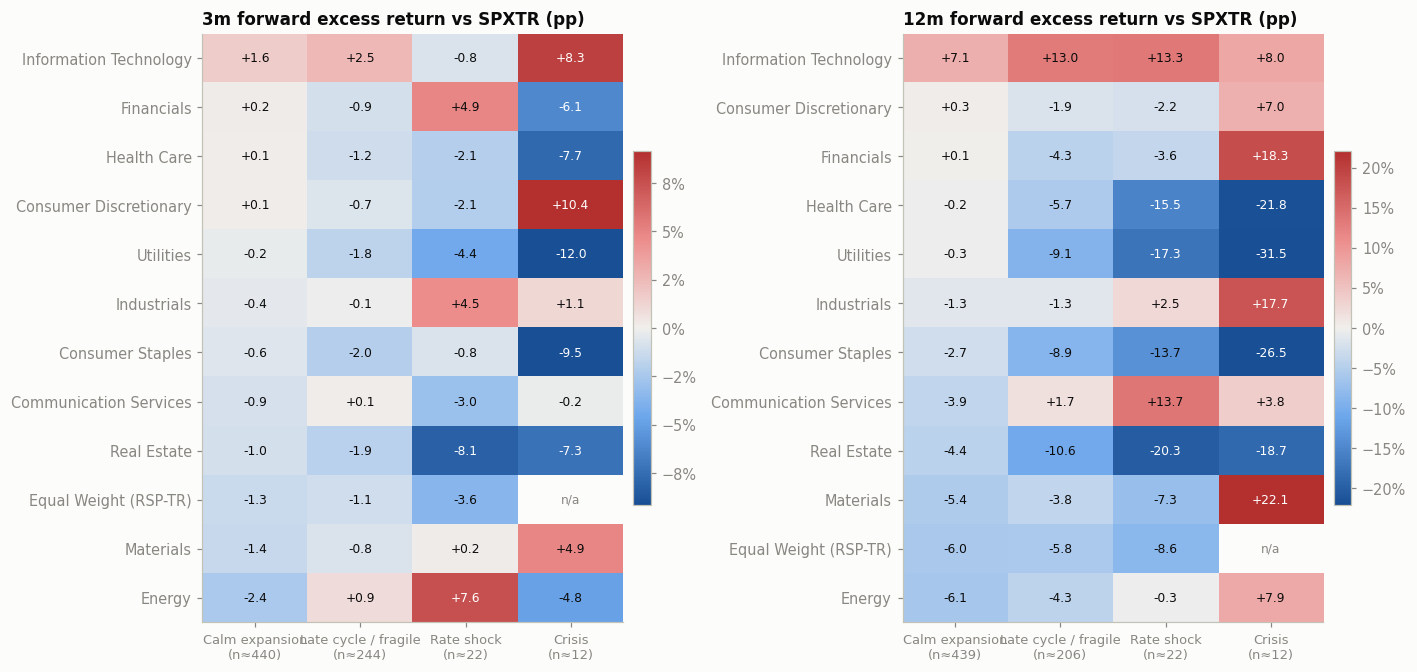

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
for ax, h in zip(axes, ['3m', '12m']):
    piv = sec_tables[h].pivot(index='sector', columns='regime', values='excess vs SPXTR').reindex(columns=ORDER) * 100
    npiv = sec_tables[h].pivot(index='sector', columns='regime', values='n').reindex(columns=ORDER)
    piv = piv.loc[piv['Calm expansion'].sort_values(ascending=False).index]
    npiv = npiv.loc[piv.index]
    lim = np.nanpercentile(np.abs(piv.values), 95)
    im = ax.imshow(piv.values, cmap=DIVERGING, vmin=-lim, vmax=lim, aspect='auto')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if np.isnan(v):
                ax.text(j, i, 'n/a', ha='center', va='center', fontsize=8, color=MUTED)
            else:
                ax.text(j, i, f'{v:+.1f}', ha='center', va='center', fontsize=8,
                        color='white' if abs(v) > 0.65 * lim else INK)
    ax.set_xticks(range(len(ORDER)), [f'{r}\n(n≈{int(npiv[r].max())})' for r in ORDER], fontsize=8.5)
    ax.set_yticks(range(len(piv)), piv.index)
    ax.grid(False)
    ax.set_title(f'{h} forward excess return vs SPXTR (pp)')
    fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02, format=mticker.PercentFormatter(decimals=0))
fig.tight_layout()
plt.show()

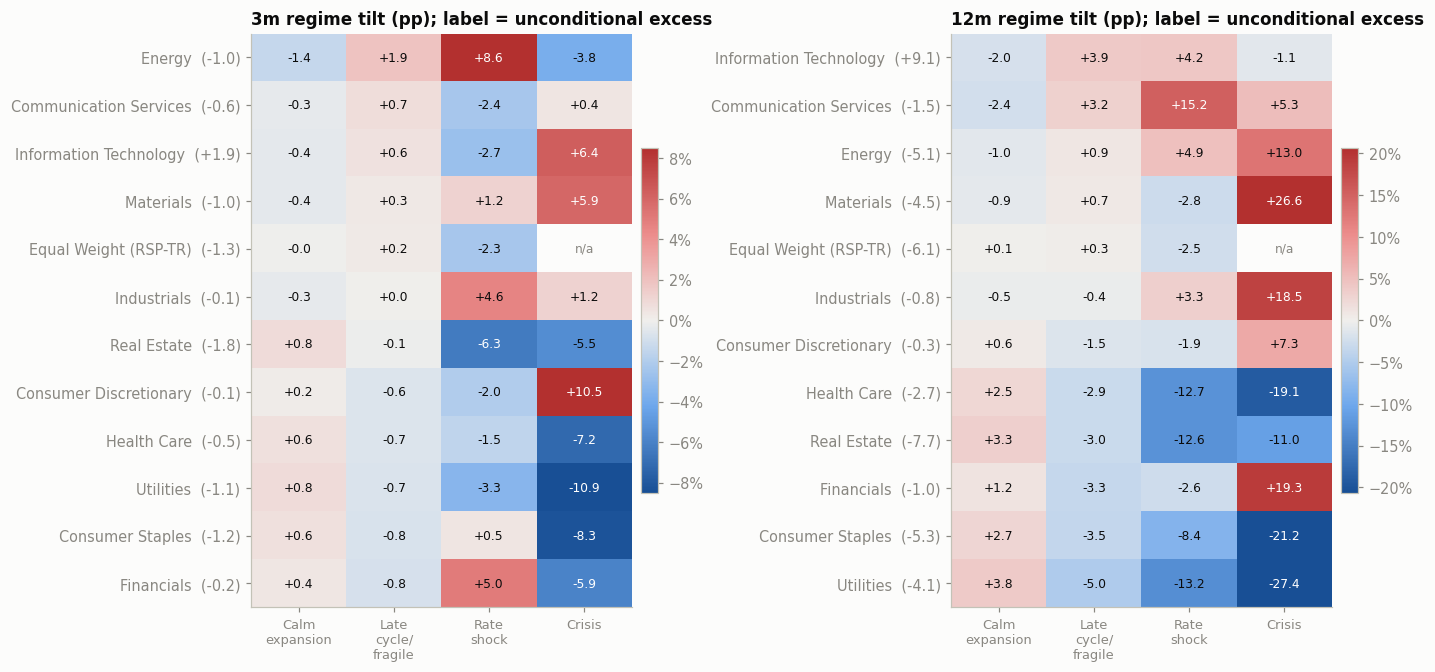

In [52]:
# Regime tilt: excess return in the regime minus the sector's unconditional excess return (same sample)
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
for ax, h in zip(axes, ['3m', '12m']):
    uncond = sec_excess[h].loc[reg_sec.index].mean() * 100
    piv = (sec_tables[h].pivot(index='sector', columns='regime', values='excess vs SPXTR')
           .reindex(columns=ORDER) * 100).sub(uncond, axis=0)
    piv = piv.loc[piv['Late cycle / fragile'].sort_values(ascending=False).index]
    lim = np.nanpercentile(np.abs(piv.values), 95)
    im = ax.imshow(piv.values, cmap=DIVERGING, vmin=-lim, vmax=lim, aspect='auto')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            ax.text(j, i, 'n/a' if np.isnan(v) else f'{v:+.1f}', ha='center', va='center', fontsize=8,
                    color=MUTED if np.isnan(v) else ('white' if abs(v) > 0.65 * lim else INK))
    ax.set_xticks(range(len(ORDER)), [r.replace(' / ', '/\n').replace(' ', '\n') for r in ORDER], fontsize=8.5)
    ax.set_yticks(range(len(piv)), [f'{s_}  ({uncond[s_]:+.1f})' for s_ in piv.index])
    ax.grid(False)
    ax.set_title(f'{h} regime tilt (pp); label = unconditional excess')
    fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02, format=mticker.PercentFormatter(decimals=0))
fig.tight_layout()
plt.show()

In [53]:
# Absolute mean forward return by regime and sector (with S&P 500 TR for reference)
abs_tab = pd.concat({
    h: sec_tables[h].pivot(index='sector', columns='regime', values='mean').reindex(columns=ORDER)
    for h in HORIZONS}, axis=1)
reg_since = reg_sec.loc[sectors.first_valid_index():]
spx_same = fwd.loc[reg_since.index].groupby(reg_since).mean().reindex(ORDER)
spx_row = pd.DataFrame([[spx_same.loc[r, h] for h in HORIZONS for r in ORDER]],
                       columns=abs_tab.columns, index=['S&P 500 (SPXTR), same weeks'])
abs_tab = pd.concat([abs_tab, spx_row])
abs_tab.style.format('{:.2%}', na_rep='–').background_gradient(cmap=SEQUENTIAL, axis=0)

In [54]:
# Full detail for the 3m and 12m horizons (excess return, outperformance hit rate, HAC t-stat, n)
detail = pd.concat({h: sec_tables[h].set_index(['regime', 'sector']) for h in ['3m', '12m']}, axis=1)
detail.style.format({c: ('{:.0f}' if c[1] == 'n' else '{:+.2f}' if c[1].startswith('t(') else
                         '{:.0%}' if c[1] in ('hit rate', 'outperform %') else '{:.2%}') for c in detail.columns},
                    na_rep='–')

In [55]:
# Sector leadership: best and worst three sectors by mean excess return in each regime
lead = []
for h in ['3m', '12m']:
    t = sec_tables[h].dropna(subset=['excess vs SPXTR'])
    t = t[t['n'] >= 8]
    for r in ORDER:
        tr = t[t.regime == r].sort_values('excess vs SPXTR', ascending=False)
        fmt = lambda d: ', '.join(f'{s} ({e:+.1%})' for s, e in zip(d.sector, d['excess vs SPXTR']))
        lead.append({'horizon': h, 'regime': r, 'leaders': fmt(tr.head(3)), 'laggards': fmt(tr.tail(3)[::-1])})
pd.DataFrame(lead).set_index(['horizon', 'regime'])

leaders                                           laggards
horizon regime                                                                                                                    
3m      Calm expansion        Information Technology (+1.6%), Financials (+0...  Energy (-2.4%), Materials (-1.4%), Equal Weigh...
        Late cycle / fragile  Information Technology (+2.5%), Energy (+0.9%)...  Consumer Staples (-2.0%), Real Estate (-1.9%),...
        Rate shock            Energy (+7.6%), Financials (+4.9%), Industrial...  Real Estate (-8.1%), Utilities (-4.4%), Equal ...
        Crisis                Consumer Discretionary (+10.4%), Information T...  Utilities (-12.0%), Consumer Staples (-9.5%), ...
12m     Calm expansion        Information Technology (+7.1%), Consumer Discr...  Energy (-6.1%), Equal Weight (RSP-TR) (-6.0%),...
        Late cycle / fragile  Information Technology (+13.0%), Communication...  Real Estate (-10.6%), Utilities (-9.1%), Consu...
        Rate shock            Communication Services (+13.7%), Information T...  Real Estate (-20.3%), Utilities (-17.3%), Heal...
        Crisis                Materials (+22.1%), Financials (+18.3%), Indus...  Utilities (-31.5%), Consumer Staples (-26.5%),...

## 12. Conclusions (data through 28-Sep-2026; out-of-sample labels Jul-2011 → Sep-2026)

**Choice of K = 4.** Walk-forward out-of-sample likelihood cannot statistically separate K = 2, 3 and 4 (gaps vs. the
best K are within ~1.5 paired S.E.), whereas K ≥ 5 is significantly worse out-of-sample *and* creates regimes that
cover < 5% of weeks (too thin to estimate forward returns). K = 4 is the richest model the data supports, and each
of its regimes has a clear macro reading. Caveat: seed/bootstrap ARI for K ≥ 3 is only ~0.3–0.4 — the boundary
between the two "normal" regimes is soft, so the posterior probabilities are more informative than the hard label.

**Economic profile of the regimes (point-in-time)**

| Regime | Share | What characterises it |
|---|---|---|
| **Calm expansion** | 58% | VIX ≈ 15, realised vol ≈ 11%, drawdown ≈ −2%; steep curve (10y-2y ≈ +95 bp); negative real policy rate (≈ −0.6%); rising breakevens; gold flat; strong trailing SPXTR (+18% 12m) |
| **Late cycle / fragile** | 38% | VIX ≈ 21, realised vol ≈ 18%, drawdown ≈ −5%; flatter curve (≈ +63 bp); real policy rate ≈ 0 and higher front-end yields; wider CCC spreads; gold bid (+21% 12m, higher GVZ); weaker trailing SPXTR (+12%) |
| **Rate shock** | 3% | Front-end yields jump (3m bill ≈ +80 bp in 3m), inverted curve, MOVE ≈ 115, real policy rate ≈ +1.1%, falling breakevens and oil; SPXTR ≈ −11% from high. Episodes: Jul–Oct 2022, Aug–Oct 2024 (yen-carry unwind) |
| **Crisis** | 1.5% | VIX ≈ 42, realised vol ≈ 57%, implied correlation ≈ 63, IG OAS ≈ 250 bp / CCC ≈ 1,740 bp, yields and breakevens collapse, WTI −51%. Out-of-sample this is only COVID (Mar–May 2020) |

**Forward SPXTR returns (point-in-time, all weeks: +15.6% over 12m)**

* **Calm expansion → below-average returns** (12m +13.0%, HAC t = −2.4). Low vol and tight conditions are already
  priced; this is the only result that is statistically significant with a large number of independent episodes (48 spells).
* **Late cycle / fragile → above-average returns** (12m +18.4%, t = +1.8; 93% hit rate, 10th percentile still +5%).
  Elevated-but-not-extreme risk is compensated — a risk-premium effect, not a sell signal.
* **Rate shock → weak near term** (6m +4.2% vs +7.7%, t = −1.7), normal over 12m (+17.5%). Only 4 spells (22 weeks).
* **Crisis → very strong subsequent returns** (12m +52%), but this is **a single episode** (COVID rebound) and cannot be
  generalised; the full-sample fit including the GFC entry shows a far more modest +28% 12m.
* The pattern is robust to K: at K = 2 and K = 3 the higher-stress regime also has the higher forward return and the
  calmest regime is below average.
* **Predictive power is modest:** point-in-time OOS predictive R² is +2.8% at 12 months and negative (−3.5%) at
  3 months — useful context for positioning, not a short-term timing tool.

**Kalman filter (Section 10).** Filtering the *inputs* adds lag, loses the Rate-shock regime and lowers predictive
content; filtering the *regime probabilities* cuts regime switches by ~8% with no loss of information or detection
delay. Neither changes the conclusions — the baseline is kept.

**Sectors (Section 11, Sep-2012 onward; tilt = excess vs SPXTR relative to the sector's own average excess)**

* **Calm expansion** → defensives do relatively better (12m tilt: Utilities +3.8pp, Real Estate +3.3, Staples +2.7,
  Health Care +2.5); Tech / Communication lag their usual outperformance.
* **Late cycle / fragile** → the growth leaders extend (Information Technology +13.0pp absolute 12m excess, t ≈ 5.7;
  Communication +1.7pp) while defensives lag badly (Real Estate −10.6pp, Utilities −9.1, Staples −8.9; t ≈ −5 to −6):
  the recovery from elevated stress is led by growth, not bond proxies.
* **Rate shock** (≈ 22 weeks, mostly 2022 and 2024) → over the next 3m, Energy (+7.6pp), Financials (+4.9) and
  Industrials (+4.5) beat SPXTR; rate-sensitive Real Estate (−8.1) and Utilities (−4.4) lag — textbook
  rising-rate winners and losers, but from only ~2 episodes.
* **Crisis** (COVID only) → classic recovery rotation over 12m: Materials (+22pp), Financials (+18), Industrials
  (+18) lead; Utilities (−32), Staples (−27), Health Care (−22) lag. One episode — illustrative only.
* Information Technology beat SPXTR in almost every regime over 2012-2026 (unconditional +9pp a year over 12m); the
  tilt charts separate that secular trend from the regime effect.

**Why point-in-time matters here.** A single full-sample fit agrees with the point-in-time labels on only ~67% of
weeks: hindsight relabels a third of history. In particular the point-in-time model could not recognise the 2022
hiking cycle as a "rate shock" until mid-2022, because nothing similar existed in its 2008-2021 training data — an
unavoidable limitation of any honest regime model.

**Current state.** The latest week (28-Sep-2026) is classified **Late cycle / fragile** with ~97% probability.